In [1]:
import os
os.makedirs("/kaggle/working/src",          exist_ok=True)
os.makedirs("/kaggle/working/checkpoints",  exist_ok=True)
os.makedirs("/kaggle/working/outputs",      exist_ok=True)
print("✓ Folders created")

✓ Folders created


In [2]:
!pip install -q timm torchmetrics grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import torch
import timm
import torchmetrics

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"Device   : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"timm     : {timm.__version__}")


PyTorch  : 2.10.0+cu128
CUDA     : True
Device   : Tesla T4
timm     : 1.0.25


100%|██████████| 169M/169M [00:01<00:00, 91.7MB/s]


CIFAR-100 — Dataset Overview
Number of classes  : 100
Train samples      : 50,000
Test  samples      : 10,000
Image size         : torch.Size([3, 32, 32])  (C x H x W)
Samples per class  : 500 (train)  |  100 (test)


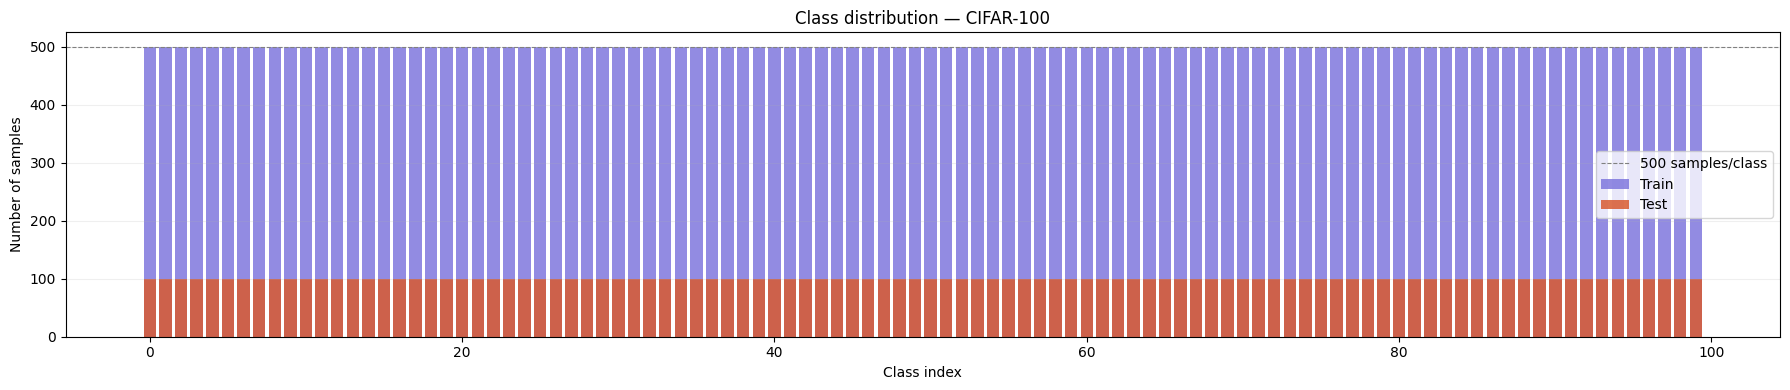

✓ Saved class_distribution.png


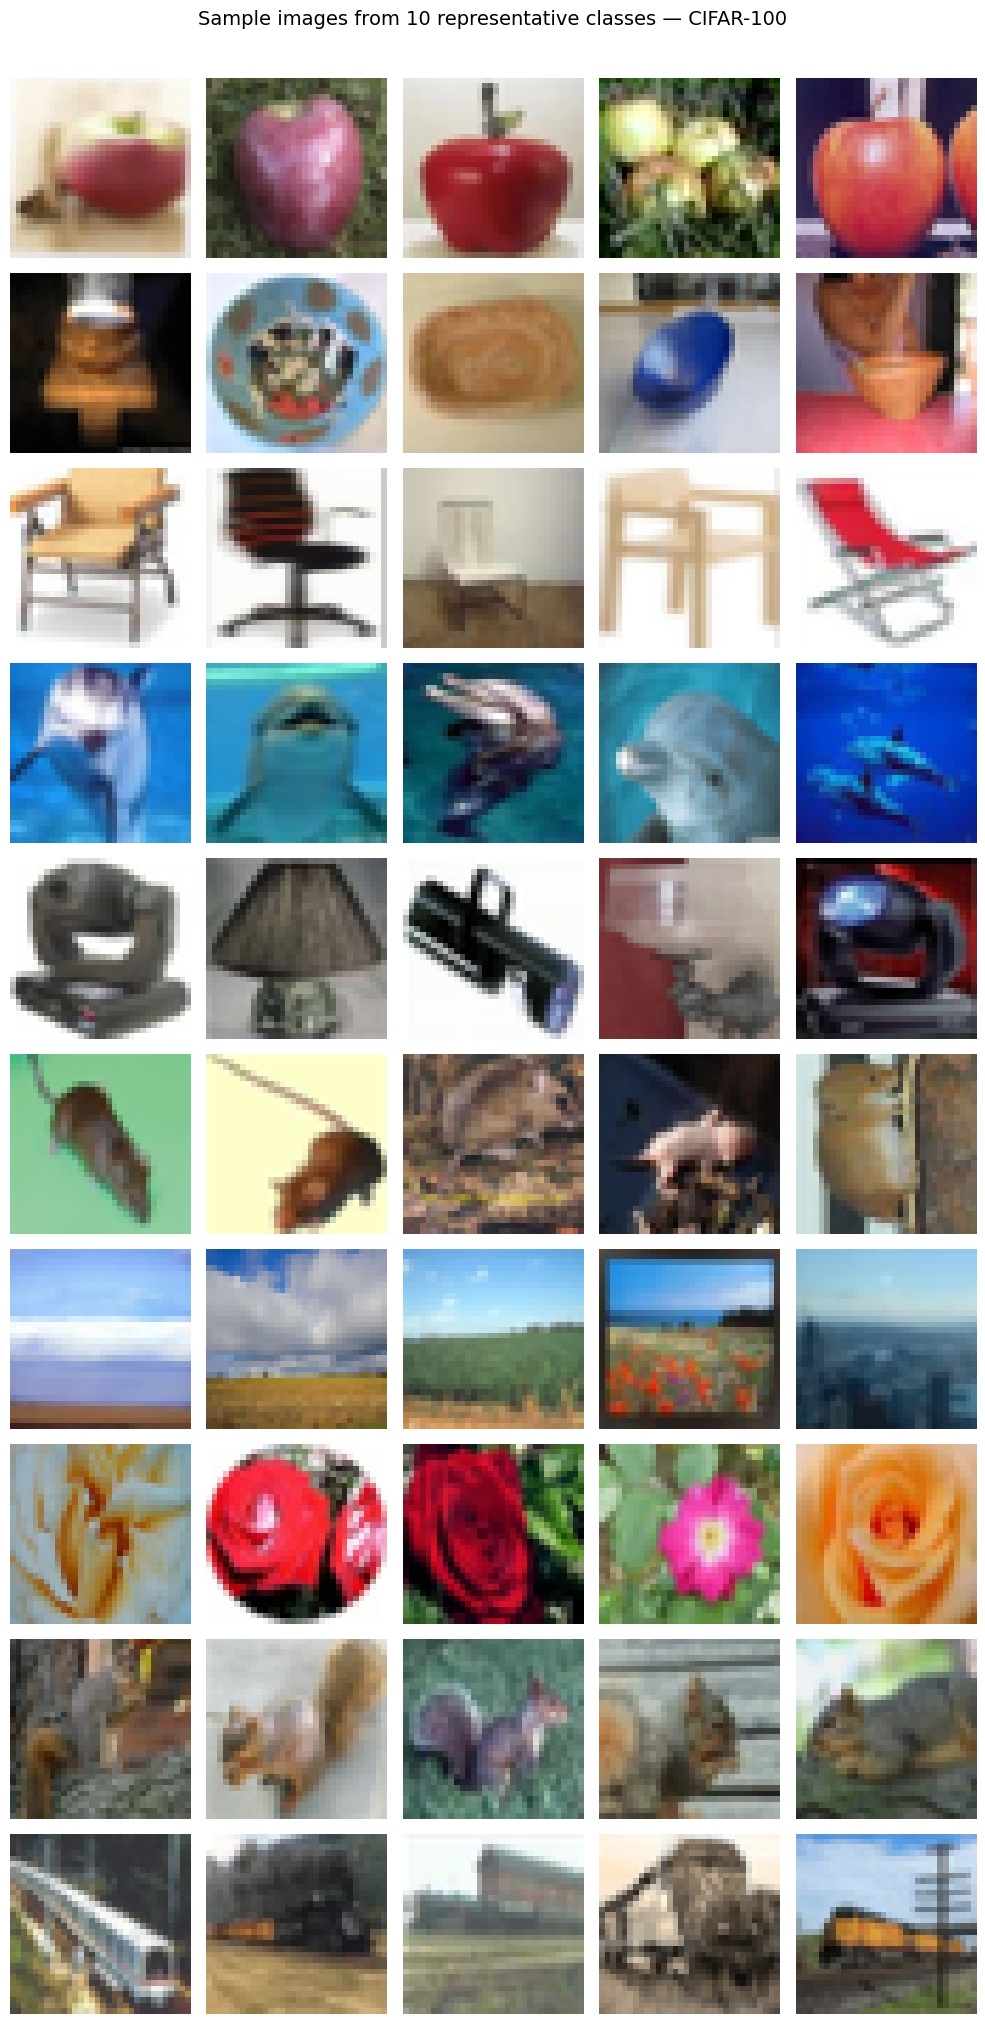

✓ Saved sample_images.png

Pixel mean (R,G,B) : [0.5071 0.4866 0.4409]
Pixel std  (R,G,B) : [0.2673 0.2564 0.2762]


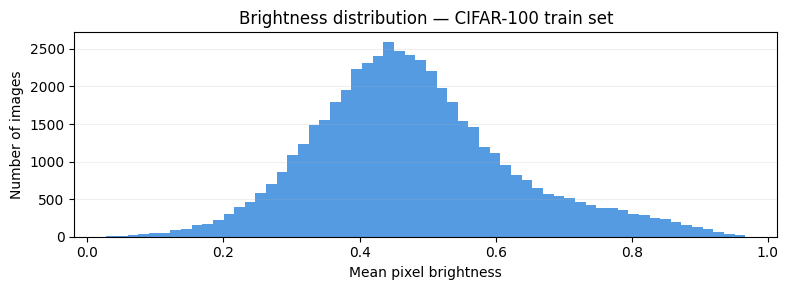

✓ Saved brightness_dist.png

✓ EDA done! Download 3 images from outputs/eda/ for your report!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from collections import Counter
import os

os.makedirs("/kaggle/working/outputs/eda", exist_ok=True)

# ── Load raw data ─────────────────────────────────────────────────────────────
raw_train = datasets.CIFAR100(root="/kaggle/working/data", train=True,  download=True, transform=transforms.ToTensor())
raw_test  = datasets.CIFAR100(root="/kaggle/working/data", train=False, download=True, transform=transforms.ToTensor())
class_names = raw_train.classes

# ── 1. Overview ───────────────────────────────────────────────────────────────
print("=" * 50)
print("CIFAR-100 — Dataset Overview")
print("=" * 50)
print(f"Number of classes  : {len(class_names)}")
print(f"Train samples      : {len(raw_train):,}")
print(f"Test  samples      : {len(raw_test):,}")
print(f"Image size         : {raw_train[0][0].shape}  (C x H x W)")
print(f"Samples per class  : {len(raw_train) // len(class_names)} (train)  |  {len(raw_test) // len(class_names)} (test)")

# ── 2. Class distribution ─────────────────────────────────────────────────────
train_labels = [label for _, label in raw_train]
test_labels  = [label for _, label in raw_test]
train_counts = [Counter(train_labels)[i] for i in range(100)]
test_counts  = [Counter(test_labels)[i]  for i in range(100)]

fig, ax = plt.subplots(figsize=(18, 4))
x = np.arange(100)
ax.bar(x, train_counts, color="#7F77DD", alpha=0.85, label="Train")
ax.bar(x, test_counts,  color="#D85A30", alpha=0.85, label="Test")
ax.axhline(y=500, color="gray", linestyle="--", linewidth=0.8, label="500 samples/class")
ax.set_xlabel("Class index")
ax.set_ylabel("Number of samples")
ax.set_title("Class distribution — CIFAR-100")
ax.legend()
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/outputs/eda/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved class_distribution.png")

# ── 3. Sample images per class ────────────────────────────────────────────────
sample_classes = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle("Sample images from 10 representative classes — CIFAR-100", fontsize=14, y=1.01)

class_images = {c: [] for c in sample_classes}
for img, label in raw_train:
    if label in class_images and len(class_images[label]) < 5:
        class_images[label].append(img)
    if all(len(v) == 5 for v in class_images.values()):
        break

for row, cls in enumerate(sample_classes):
    for col, img in enumerate(class_images[cls]):
        axes[row][col].imshow(img.permute(1, 2, 0).numpy())
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(class_names[cls], rotation=0,
                                       labelpad=60, fontsize=10, va="center")
plt.tight_layout()
plt.savefig("/kaggle/working/outputs/eda/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved sample_images.png")

# ── 4. Pixel statistics ───────────────────────────────────────────────────────
all_imgs = np.stack([img.numpy() for img, _ in raw_train])
mean = all_imgs.mean(axis=(0, 2, 3))
std  = all_imgs.std(axis=(0, 2, 3))
print(f"\nPixel mean (R,G,B) : {mean.round(4)}")
print(f"Pixel std  (R,G,B) : {std.round(4)}")

# ── 5. Brightness distribution ────────────────────────────────────────────────
brightness = all_imgs.mean(axis=(1, 2, 3))
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(brightness, bins=60, color="#378ADD", alpha=0.85, edgecolor="none")
ax.set_xlabel("Mean pixel brightness")
ax.set_ylabel("Number of images")
ax.set_title("Brightness distribution — CIFAR-100 train set")
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/outputs/eda/brightness_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved brightness_dist.png")

print("\n✓ EDA done! Download 3 images from outputs/eda/ for your report!")

In [5]:
%%writefile /kaggle/working/src/dataset.py
import torch
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

IMG_SIZE = 96

TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomCrop(IMG_SIZE, padding=12),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5071, 0.4867, 0.4408],
        std =[0.2675, 0.2565, 0.2761]
    ),
])

VAL_TRANSFORMS = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5071, 0.4867, 0.4408],
        std =[0.2675, 0.2565, 0.2761]
    ),
])

def get_dataloaders(data_dir="/kaggle/working/data", batch_size=128, val_split=0.2):
    full_train_aug = datasets.CIFAR100(root=data_dir, train=True,  download=True,  transform=TRAIN_TRANSFORMS)
    full_train_val = datasets.CIFAR100(root=data_dir, train=True,  download=False, transform=VAL_TRANSFORMS)
    test_set       = datasets.CIFAR100(root=data_dir, train=False, download=False, transform=VAL_TRANSFORMS)

    n_val   = int(len(full_train_aug) * val_split)
    n_train = len(full_train_aug) - n_val
    generator = torch.Generator().manual_seed(42)
    train_idx, val_idx = random_split(range(len(full_train_aug)), [n_train, n_val], generator=generator)

    train_loader = DataLoader(Subset(full_train_aug, train_idx.indices),
                              batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(Subset(full_train_val, val_idx.indices),
                              batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,
                              batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, 100, full_train_aug.classes


Writing /kaggle/working/src/dataset.py


Class: cattle


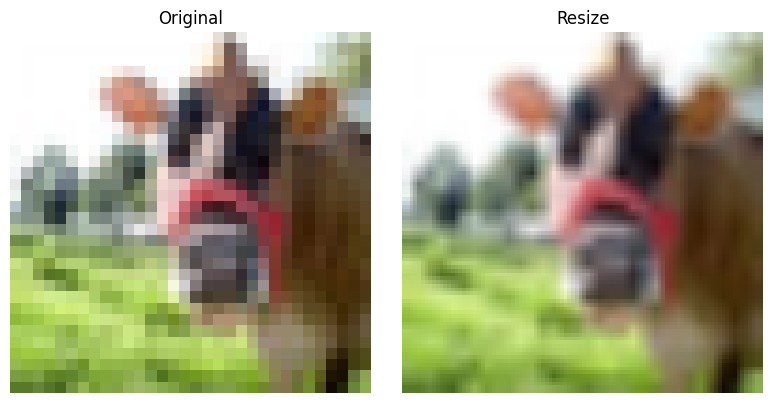

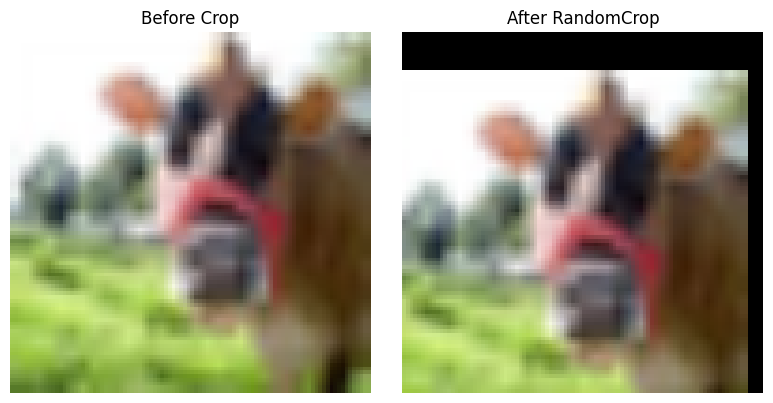

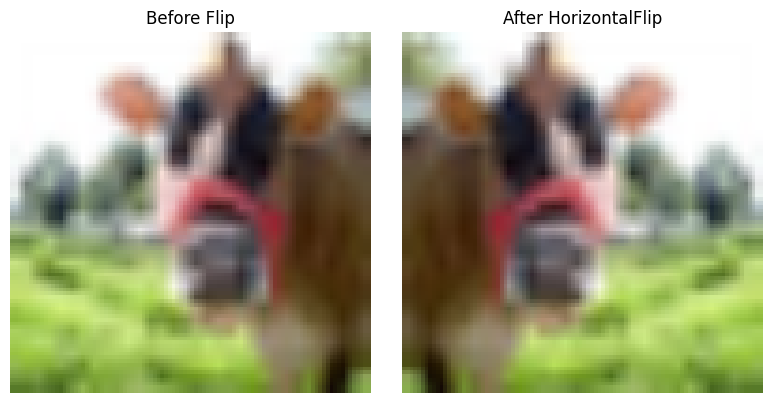

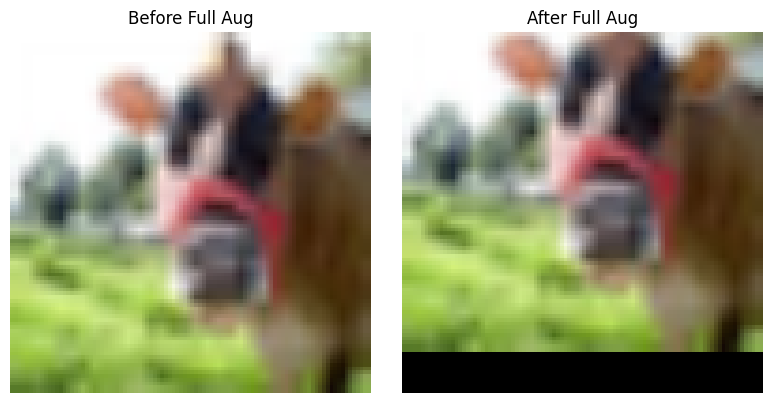

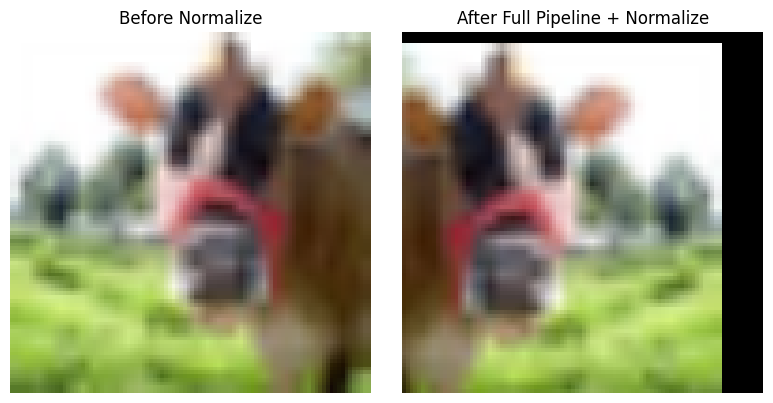

In [6]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

IMG_SIZE = 96

# mean/std của CIFAR-100
MEAN = [0.5071, 0.4867, 0.4408]
STD  = [0.2675, 0.2565, 0.2761]

# ---------------------------
# 1. Các augmentation riêng lẻ
# ---------------------------
resize_tf = transforms.Resize((IMG_SIZE, IMG_SIZE))
crop_tf   = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=12),
])
flip_tf   = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),  # ép chắc chắn flip để dễ quan sát
])

# full train transform của bạn
train_tf_no_norm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=12),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

train_tf_with_norm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=12),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# ---------------------------
# 2. Hàm unnormalize để vẽ ảnh
# ---------------------------
def unnormalize(img_tensor, mean=MEAN, std=STD):
    """
    img_tensor: Tensor dạng [C, H, W]
    """
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img_tensor = img_tensor * std + mean
    return torch.clamp(img_tensor, 0, 1)

# ---------------------------
# 3. Hàm hiển thị trước/sau
# ---------------------------
def show_before_after(original_pil, augmented, title_before="Before", title_after="After"):
    """
    original_pil: ảnh PIL gốc
    augmented: có thể là PIL hoặc Tensor
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # ảnh trước
    axes[0].imshow(original_pil)
    axes[0].set_title(title_before)
    axes[0].axis("off")

    # ảnh sau
    if isinstance(augmented, torch.Tensor):
        # nếu là tensor thì đổi về HWC để show
        img = augmented
        if img.min() < 0 or img.max() > 1:
            img = unnormalize(img)
        img = img.permute(1, 2, 0).cpu().numpy()
        axes[1].imshow(img)
    else:
        axes[1].imshow(augmented)

    axes[1].set_title(title_after)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# ---------------------------
# 4. Load CIFAR-100 gốc (không transform)
# ---------------------------
data_dir = "/kaggle/working/data"
raw_dataset = datasets.CIFAR100(root=data_dir, train=True, download=True, transform=None)

# chọn 1 ảnh mẫu
idx = 0
img, label = raw_dataset[idx]

print("Class:", raw_dataset.classes[label])

# ---------------------------
# 5. Hiển thị từng augmentation
# ---------------------------

# 5.1 Resize
img_resize = resize_tf(img)
show_before_after(img, img_resize, "Original", "Resize")

# 5.2 RandomCrop
img_crop = crop_tf(img)
show_before_after(img_resize, img_crop, "Before Crop", "After RandomCrop")

# 5.3 HorizontalFlip
img_flip = flip_tf(img)
show_before_after(img_resize, img_flip, "Before Flip", "After HorizontalFlip")

# 5.4 Full augmentation pipeline (chưa normalize để dễ nhìn)
img_full_aug = train_tf_no_norm(img)
show_before_after(img_resize, img_full_aug, "Before Full Aug", "After Full Aug")

# 5.5 Full pipeline có normalize -> unnormalize để hiển thị
img_full_norm = train_tf_with_norm(img)
show_before_after(img_resize, img_full_norm, "Before Normalize", "After Full Pipeline + Normalize")

In [7]:
import sys
sys.path.append("/kaggle/working")

from src.dataset import get_dataloaders

train_loader, val_loader, test_loader, num_classes, class_names = get_dataloaders(
    batch_size  = 64,
)

# Quick check
images, labels = next(iter(train_loader))
print(f"✓ Train batches : {len(train_loader)}")
print(f"✓ Val   batches : {len(val_loader)}")
print(f"✓ Test  batches : {len(test_loader)}")
print(f"✓ Image shape   : {images.shape}")   # should be [32, 3, 224, 224]
print(f"✓ Num classes   : {num_classes}")
print(f"✓ Sample classes: {class_names[:5]}")
# ```

# You should see:
# ```
# ✓ Train batches : 1407
# ✓ Val   batches : 157
# ✓ Test  batches : 313
# ✓ Image shape   : torch.Size([32, 3, 224, 224])
# ✓ Num classes   : 100
# ✓ Sample classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']

✓ Train batches : 625
✓ Val   batches : 157
✓ Test  batches : 157
✓ Image shape   : torch.Size([64, 3, 96, 96])
✓ Num classes   : 100
✓ Sample classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']


In [8]:
%%writefile /kaggle/working/src/model.py
import timm

IMG_SIZE = 96

SUPPORTED_MODELS = {
    "resnet50"                     : "CNN",
    "efficientnet_b3"              : "CNN",
    "swin_tiny_patch4_window7_224" : "ViT",
    "vit_base_patch16_224"         : "ViT",
}

def build_model(arch: str, num_classes: int = 100, pretrained: bool = True):
    assert arch in SUPPORTED_MODELS, f"Unknown arch '{arch}'. Choose from: {list(SUPPORTED_MODELS.keys())}"
    is_vit = SUPPORTED_MODELS[arch] == "ViT"
    model  = timm.create_model(
        arch,
        pretrained   = pretrained,
        num_classes  = num_classes,
        **({"img_size": IMG_SIZE} if is_vit else {})
    )
    params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    print(f"✓ Built {arch} ({SUPPORTED_MODELS[arch]}) — {params:.1f}M params")
    return model

def get_optimizer_groups(model, head_lr=1e-4, backbone_lr=1e-5):
    head_keys = ["head", "classifier", "fc"]
    head_params     = [p for n,p in model.named_parameters() if     any(k in n for k in head_keys)]
    backbone_params = [p for n,p in model.named_parameters() if not any(k in n for k in head_keys)]
    return [
        {"params": head_params,     "lr": head_lr},
        {"params": backbone_params, "lr": backbone_lr},
    ]

def freeze_backbone(model):
    head_keys = ["head", "classifier", "fc"]
    for name, param in model.named_parameters():
        if not any(k in name for k in head_keys):
            param.requires_grad = False
    print("Backbone frozen — only head is trainable")
    return model

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    print("All layers unfrozen")
    return model

Writing /kaggle/working/src/model.py


In [9]:
import sys
sys.path.append("/kaggle/working")

from src.model import build_model

archs = [
    "resnet50",
    "efficientnet_b3",
    "swin_tiny_patch4_window7_224",
    "vit_base_patch16_224",
]

for arch in archs:
    model = build_model(arch, num_classes=100)
# ```

# Expected output:
# ```
# ✓ Built resnet50 (CNN) — 23.7M params
# ✓ Built efficientnet_b3 (CNN) — 10.7M params
# ✓ Built swin_tiny_patch4_window7_224 (ViT) — 27.5M params
# ✓ Built vit_base_patch16_224 (ViT) — 85.8M params

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

✓ Built resnet50 (CNN) — 23.7M params


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✓ Built efficientnet_b3 (CNN) — 10.8M params


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  idx_right = torch.bucketize(x, p)
/usr/local/lib/python3.12/dist-packages/timm/layers/interpolate.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  numerator += self.values[as_s] * \


✓ Built swin_tiny_patch4_window7_224 (ViT) — 27.6M params


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✓ Built vit_base_patch16_224 (ViT) — 85.8M params


In [10]:
%%writefile /kaggle/working/src/train.py
"""
TN1 — Fine-tune toàn bộ với differential learning rate
=======================================================
Train thẳng toàn bộ model từ đầu, không freeze.
head_lr > backbone_lr để bảo vệ pretrained weights.
Giống code gốc, chỉ tăng lên 25 epoch và batch_size=128.
"""
import time
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchmetrics import Accuracy, F1Score
from src.model import get_optimizer_groups


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, num_classes, device):
    model.eval()
    acc = Accuracy(task="multiclass", num_classes=num_classes).to(device)
    f1  = F1Score(task="multiclass",  num_classes=num_classes, average="macro").to(device)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        acc.update(preds, labels)
        f1.update(preds, labels)
    return acc.compute().item(), f1.compute().item()


def train(model, train_loader, val_loader, num_classes,
          arch="model", epochs=25,
          head_lr=1e-4, backbone_lr=1e-5,
          label_smoothing=0.1, weight_decay=1e-4):

    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = AdamW(get_optimizer_groups(model, head_lr, backbone_lr),
                      weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0.0
    history  = {"train_loss": [], "val_acc": [], "val_f1": []}
    ckpt_path = f"/kaggle/working/checkpoints/{arch}_best.pth"

    print(f"\n{'─'*55}")
    print(f"  Training : {arch}  |  device: {device}")
    print(f"  Epochs   : {epochs}  |  head_lr: {head_lr}  |  backbone_lr: {backbone_lr}")
    print(f"  Strategy : TN1 — fine-tune all, differential lr, no freeze")
    print(f"{'─'*55}")

    for epoch in range(1, epochs + 1):
        t0         = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_acc, val_f1 = evaluate(model, val_loader, num_classes, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        marker = " (new best)" if val_acc > best_acc else ""
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), ckpt_path)

        print(f"  Epoch {epoch:02d}/{epochs} | loss={train_loss:.4f} | "
              f"val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | {time.time()-t0:.0f}s{marker}")

    print(f"{'─'*55}")
    print(f"  Best val_acc: {best_acc:.4f}  →  checkpoints/{arch}_best.pth")
    return history


Writing /kaggle/working/src/train.py


In [11]:
%%writefile /kaggle/working/src/evaluate.py
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torchmetrics import Accuracy, F1Score
from torchmetrics.classification import MulticlassConfusionMatrix

# ── Full evaluation on test set ──────────────────────────────────────────────

@torch.no_grad()
def evaluate_test(model, loader, num_classes, class_names, device):
    model.eval()
    acc  = Accuracy(task="multiclass", num_classes=num_classes).to(device)
    f1   = F1Score(task="multiclass",  num_classes=num_classes, average="macro").to(device)
    f1pc = F1Score(task="multiclass",  num_classes=num_classes, average="none").to(device)
    cm   = MulticlassConfusionMatrix(num_classes=num_classes).to(device)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        acc.update(preds, labels)
        f1.update(preds, labels)
        f1pc.update(preds, labels)
        cm.update(preds, labels)

    results = {
        "accuracy"     : acc.compute().item(),
        "f1_macro"     : f1.compute().item(),
        "f1_per_class" : f1pc.compute().cpu().numpy(),
        "confusion_matrix": cm.compute().cpu().numpy(),
    }
    return results

# ── Plot training curves ─────────────────────────────────────────────────────

def plot_history(histories: dict, save_path="/kaggle/working/outputs/training_curves.png"):
    """
    histories = {"resnet50": history_dict, "efficientnet_b3": history_dict, ...}
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ["#1D9E75", "#E8593C", "#3B8BD4", "#BA7517"]

    for (arch, h), color in zip(histories.items(), colors):
        epochs = range(1, len(h["train_loss"]) + 1)
        axes[0].plot(epochs, h["train_loss"], label=arch, color=color)
        axes[1].plot(epochs, h["val_acc"],    label=arch, color=color)

    axes[0].set_title("Training loss",    fontsize=13)
    axes[1].set_title("Validation accuracy", fontsize=13)
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {save_path}")

# ── Plot confusion matrix ────────────────────────────────────────────────────

def plot_confusion_matrix(cm, class_names, arch,
                          save_path=None):
    """Plot a readable confusion matrix (shows top-20 classes for readability)."""
    # For 100 classes, only show top 20 most-confused classes
    per_class_errors = cm.sum(axis=1) - np.diag(cm)
    top20_idx = np.argsort(per_class_errors)[-20:][::-1]
    cm_sub    = cm[np.ix_(top20_idx, top20_idx)]
    labels    = [class_names[i] for i in top20_idx]

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_sub, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set(xticks=range(20), yticks=range(20),
           xticklabels=labels, yticklabels=labels,
           xlabel="Predicted", ylabel="True",
           title=f"Confusion matrix — {arch} (top-20 most confused classes)")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    plt.tight_layout()

    path = save_path or f"/kaggle/working/outputs/cm_{arch}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {path}")

# ── Print comparison table ───────────────────────────────────────────────────

def print_results_table(all_results: dict):
    """
    all_results = {"resnet50": results_dict, ...}
    """
    print(f"\n{'─'*55}")
    print(f"  {'Model':<35} {'Accuracy':>8}  {'F1 macro':>8}")
    print(f"{'─'*55}")
    for arch, r in all_results.items():
        print(f"  {arch:<35} {r['accuracy']:>8.4f}  {r['f1_macro']:>8.4f}")
    print(f"{'─'*55}\n")


Writing /kaggle/working/src/evaluate.py


In [12]:
import sys, importlib
sys.path.append("/kaggle/working")

import src.dataset, src.train, src.model
importlib.reload(src.dataset)
importlib.reload(src.model)
importlib.reload(src.train)

from src.dataset import get_dataloaders
from src.model   import build_model
from src.train   import train
from torch.utils.data import Subset, DataLoader

# ── Data ──────────────────────────────────────────────────────────────────────
train_loader, val_loader, test_loader, num_classes, class_names = get_dataloaders(batch_size=64)

# Subset nhỏ cho smoke test
small_train = DataLoader(Subset(train_loader.dataset, range(640)), batch_size=64, shuffle=True,  num_workers=0)
small_val   = DataLoader(Subset(val_loader.dataset,   range(128)), batch_size=64, shuffle=False, num_workers=0)

# ── Smoke test 4 models, mỗi cái 1 epoch ─────────────────────────────────────
experiments = [
    "resnet50",
    "efficientnet_b3",
    "swin_tiny_patch4_window7_224",
    "vit_base_patch16_224",
]

for arch in experiments:
    print(f"\nTest: {arch}")
    model   = build_model(arch, num_classes=100)
    history = train(model, small_train, small_val, num_classes, arch=arch, epochs=1)
    print(f"✓ Passed: {arch}")

print("\n All models smoke test passed!")


Test: resnet50
✓ Built resnet50 (CNN) — 23.7M params

───────────────────────────────────────────────────────
  Training : resnet50  |  device: cuda
  Epochs   : 1  |  head_lr: 0.0001  |  backbone_lr: 1e-05
  Strategy : TN1 — fine-tune all, differential lr, no freeze
───────────────────────────────────────────────────────
  Epoch 01/1 | loss=4.6050 | val_acc=0.0312 | val_f1=0.0138 | 3s (new best)
───────────────────────────────────────────────────────
  Best val_acc: 0.0312  →  checkpoints/resnet50_best.pth
✓ Passed: resnet50

Test: efficientnet_b3
✓ Built efficientnet_b3 (CNN) — 10.8M params

───────────────────────────────────────────────────────
  Training : efficientnet_b3  |  device: cuda
  Epochs   : 1  |  head_lr: 0.0001  |  backbone_lr: 1e-05
  Strategy : TN1 — fine-tune all, differential lr, no freeze
───────────────────────────────────────────────────────
  Epoch 01/1 | loss=5.1077 | val_acc=0.0000 | val_f1=0.0000 | 2s
───────────────────────────────────────────────────────


In [13]:
%%writefile /kaggle/working/src/evaluate.py
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torchmetrics import Accuracy, F1Score
from torchmetrics.classification import MulticlassConfusionMatrix

# ── Full evaluation on test set ──────────────────────────────────────────────

@torch.no_grad()
def evaluate_test(model, loader, num_classes, class_names, device):
    model.eval()
    acc  = Accuracy(task="multiclass", num_classes=num_classes).to(device)
    f1   = F1Score(task="multiclass",  num_classes=num_classes, average="macro").to(device)
    f1pc = F1Score(task="multiclass",  num_classes=num_classes, average="none").to(device)
    cm   = MulticlassConfusionMatrix(num_classes=num_classes).to(device)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        acc.update(preds, labels)
        f1.update(preds, labels)
        f1pc.update(preds, labels)
        cm.update(preds, labels)

    results = {
        "accuracy"     : acc.compute().item(),
        "f1_macro"     : f1.compute().item(),
        "f1_per_class" : f1pc.compute().cpu().numpy(),
        "confusion_matrix": cm.compute().cpu().numpy(),
    }
    return results

# ── Plot training curves ─────────────────────────────────────────────────────

def plot_history(histories: dict, save_path="/kaggle/working/outputs/training_curves.png"):
    """
    histories = {"resnet50": history_dict, "efficientnet_b3": history_dict, ...}
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ["#1D9E75", "#E8593C", "#3B8BD4", "#BA7517"]

    for (arch, h), color in zip(histories.items(), colors):
        epochs = range(1, len(h["train_loss"]) + 1)
        axes[0].plot(epochs, h["train_loss"], label=arch, color=color)
        axes[1].plot(epochs, h["val_acc"],    label=arch, color=color)

    axes[0].set_title("Training loss",    fontsize=13)
    axes[1].set_title("Validation accuracy", fontsize=13)
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {save_path}")

# ── Plot confusion matrix ────────────────────────────────────────────────────

def plot_confusion_matrix(cm, class_names, arch,
                          save_path=None):
    """Plot a readable confusion matrix (shows top-20 classes for readability)."""
    # For 100 classes, only show top 20 most-confused classes
    per_class_errors = cm.sum(axis=1) - np.diag(cm)
    top20_idx = np.argsort(per_class_errors)[-20:][::-1]
    cm_sub    = cm[np.ix_(top20_idx, top20_idx)]
    labels    = [class_names[i] for i in top20_idx]

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_sub, interpolation="nearest", cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set(xticks=range(20), yticks=range(20),
           xticklabels=labels, yticklabels=labels,
           xlabel="Predicted", ylabel="True",
           title=f"Confusion matrix — {arch} (top-20 most confused classes)")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    plt.tight_layout()

    path = save_path or f"/kaggle/working/outputs/cm_{arch}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved → {path}")

# ── Print comparison table ───────────────────────────────────────────────────

def print_results_table(all_results: dict):
    """
    all_results = {"resnet50": results_dict, ...}
    """
    print(f"\n{'─'*55}")
    print(f"  {'Model':<35} {'Accuracy':>8}  {'F1 macro':>8}")
    print(f"{'─'*55}")
    for arch, r in all_results.items():
        print(f"  {arch:<35} {r['accuracy']:>8.4f}  {r['f1_macro']:>8.4f}")
    print(f"{'─'*55}\n")

Overwriting /kaggle/working/src/evaluate.py


In [14]:
import sys, os, torch, pandas as pd, importlib
sys.path.append("/kaggle/working")

os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/outputs",     exist_ok=True)

import src.dataset, src.model, src.train
importlib.reload(src.dataset); importlib.reload(src.model); importlib.reload(src.train)

from src.dataset import get_dataloaders
from src.model   import build_model
from src.train   import train

train_loader, val_loader, test_loader, num_classes, class_names = get_dataloaders(batch_size=128)

experiments = [
    dict(arch="resnet50",                     epochs=25),
    dict(arch="efficientnet_b3",              epochs=25),
    dict(arch="swin_tiny_patch4_window7_224", epochs=20),
    dict(arch="vit_base_patch16_224",         epochs=20),
]

all_histories = {}
for exp in experiments:
    arch  = exp.pop("arch")
    model = build_model(arch, num_classes=100, pretrained=True)
    history = train(model, train_loader, val_loader, num_classes,
                    arch=arch, head_lr=1e-4, backbone_lr=1e-5, **exp)
    all_histories[arch] = history
    print(f"\n✓ Done: {arch}\n")

rows = []
for arch, h in all_histories.items():
    for ep, (loss, acc, f1) in enumerate(
        zip(h["train_loss"], h["val_acc"], h["val_f1"]), 1):
        rows.append(dict(model=arch, epoch=ep,
                         train_loss=loss, val_acc=acc, val_f1=f1))
pd.DataFrame(rows).to_csv("/kaggle/working/outputs/training_history.csv", index=False)
print("✓ Saved → outputs/training_history.csv")


✓ Built resnet50 (CNN) — 23.7M params

───────────────────────────────────────────────────────
  Training : resnet50  |  device: cuda
  Epochs   : 25  |  head_lr: 0.0001  |  backbone_lr: 1e-05
  Strategy : TN1 — fine-tune all, differential lr, no freeze
───────────────────────────────────────────────────────
  Epoch 01/25 | loss=4.2063 | val_acc=0.4258 | val_f1=0.4053 | 97s (new best)
  Epoch 02/25 | loss=3.1353 | val_acc=0.5448 | val_f1=0.5247 | 104s (new best)
  Epoch 03/25 | loss=2.4112 | val_acc=0.6117 | val_f1=0.6000 | 103s (new best)
  Epoch 04/25 | loss=2.0908 | val_acc=0.6501 | val_f1=0.6413 | 104s (new best)
  Epoch 05/25 | loss=1.9316 | val_acc=0.6693 | val_f1=0.6631 | 104s (new best)
  Epoch 06/25 | loss=1.8253 | val_acc=0.6894 | val_f1=0.6840 | 104s (new best)
  Epoch 07/25 | loss=1.7479 | val_acc=0.6996 | val_f1=0.6941 | 104s (new best)
  Epoch 08/25 | loss=1.6974 | val_acc=0.7082 | val_f1=0.7039 | 104s (new best)
  Epoch 09/25 | loss=1.6573 | val_acc=0.7166 | val_f1=0.712

In [15]:
!kaggle kernels output thinguynmnh/ngunguc -p /path/to/dest

Output file downloaded to /path/to/dest/checkpoints/efficientnet_b3_best.pth
Output file downloaded to /path/to/dest/checkpoints/resnet50_best.pth
Output file downloaded to /path/to/dest/checkpoints/swin_tiny_patch4_window7_224_best.pth
Output file downloaded to /path/to/dest/checkpoints/vit_base_patch16_224_best.pth
Output file downloaded to /path/to/dest/data/cifar-100-python.tar.gz
Output file downloaded to /path/to/dest/data/cifar-100-python/file.txt~
Output file downloaded to /path/to/dest/data/cifar-100-python/meta
Output file downloaded to /path/to/dest/data/cifar-100-python/test
Output file downloaded to /path/to/dest/data/cifar-100-python/train
Output file downloaded to /path/to/dest/outputs/eda/brightness_dist.png
Output file downloaded to /path/to/dest/outputs/eda/class_distribution.png
Output file downloaded to /path/to/dest/outputs/eda/sample_images.png
Output file downloaded to /path/to/dest/src/__pycache__/dataset.cpython-312.pyc
Output file downloaded to /path/to/dest/s

In [16]:
import os
for root, dirs, files in os.walk("/path/to/dest"):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))

/path/to/dest/checkpoints/resnet50_best.pth
/path/to/dest/checkpoints/vit_base_patch16_224_best.pth
/path/to/dest/checkpoints/swin_tiny_patch4_window7_224_best.pth
/path/to/dest/checkpoints/efficientnet_b3_best.pth


In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# CIFAR-100 fine-class order (torchvision / same as your dataloaders' class_names)
FINE_NAMES = (
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle",
    "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle",
    "caterpillar", "cattle", "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch",
    "crab", "crocodile", "cup", "dinosaur", "dolphin", "elephant", "flatfish", "forest",
    "fox", "girl", "hamster", "house", "kangaroo", "keyboard", "lamp", "lawn_mower",
    "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine", "possum",
    "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea", "seal", "shark", "shrew",
    "skunk", "skyscraper", "snail", "snake", "spider", "squirrel", "streetcar", "sunflower",
    "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor", "train",
    "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm",
)

SUPERCLASSES = {
    "aquatic mammals": ("beaver", "dolphin", "otter", "seal", "whale"),
    "fish": ("aquarium_fish", "flatfish", "ray", "shark", "trout"),
    "flowers": ("orchid", "poppy", "rose", "sunflower", "tulip"),
    "food containers": ("bottle", "bowl", "can", "cup", "plate"),
    "fruit and vegetables": ("apple", "mushroom", "orange", "pear", "sweet_pepper"),
    "household electrical": ("clock", "keyboard", "lamp", "telephone", "television"),
    "household furniture": ("bed", "chair", "couch", "table", "wardrobe"),
    "insects": ("bee", "beetle", "butterfly", "caterpillar", "cockroach"),
    "large carnivores": ("bear", "leopard", "lion", "tiger", "wolf"),
    "large outdoor man-made": ("bridge", "castle", "house", "road", "skyscraper"),
    "large outdoor natural": ("cloud", "forest", "mountain", "plain", "sea"),
    "large omnivores/herbivores": ("camel", "cattle", "chimpanzee", "elephant", "kangaroo"),
    "medium mammals": ("fox", "porcupine", "possum", "raccoon", "skunk"),
    "invertebrates": ("crab", "lobster", "snail", "spider", "worm"),
    "people": ("baby", "boy", "girl", "man", "woman"),
    "reptiles": ("crocodile", "dinosaur", "lizard", "snake", "turtle"),
    "small mammals": ("hamster", "mouse", "rabbit", "shrew", "squirrel"),
    "trees": ("maple_tree", "oak_tree", "palm_tree", "pine_tree", "willow_tree"),
    "vehicles 1": ("bicycle", "bus", "motorcycle", "pickup_truck", "train"),
    "vehicles 2": ("lawn_mower", "rocket", "streetcar", "tank", "tractor"),
}

super_to_classes = [[FINE_NAMES.index(n) for n in subs] for subs in SUPERCLASSES.values()]
super_names = list(SUPERCLASSES.keys())

@torch.no_grad()
def get_predictions(model, loader, device):
    """Run model on loader; return (preds, labels) as 1D numpy int arrays."""
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def plot_inter_superclass(preds, labels, class_names, arch, save_dir):
    """Panel 1: 20×20 superclass confusion matrix"""
    cm100    = confusion_matrix(labels, preds, labels=list(range(100)))
    super_cm = np.zeros((20, 20))
    for si in range(20):
        for sj in range(20):
            ri = super_to_classes[si]
            ci = super_to_classes[sj]
            super_cm[si, sj] = cm100[np.ix_(ri, ci)].sum()
    super_cm_norm = super_cm / super_cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(super_cm_norm, cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="Proportion")
    ax.set_xticks(range(20)); ax.set_yticks(range(20))
    ax.set_xticklabels(super_names, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(super_names, fontsize=9)
    ax.set_xlabel("Predicted superclass", fontsize=11)
    ax.set_ylabel("True superclass",      fontsize=11)
    ax.set_title(f"Inter-superclass confusion — {arch}\n"
                 f"Diagonal = correct rate  |  Off-diagonal = wrong superclass rate", fontsize=12)
    for i in range(20):
        for j in range(20):
            val = super_cm_norm[i, j]
            if val > 0.01:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=6.5, color="white" if val > 0.5 else "black")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/1_inter_superclass_{arch}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"✓ Saved 1_inter_superclass_{arch}.png")
    return cm100, super_cm


def plot_intra_superclass(cm100, super_cm, arch, save_dir):
    """Panel 2: Intra-superclass confusion bar chart"""
    intra_error = np.zeros(20)
    for si in range(20):
        ri = super_to_classes[si]
        intra_correct_super = super_cm[si, si]
        intra_correct_class = cm100[np.ix_(ri, ri)].diagonal().sum()
        if intra_correct_super > 0:
            intra_error[si] = 1 - intra_correct_class / intra_correct_super

    colors = ["#E24B4A" if e > 0.15 else "#EF9F27" if e > 0.08 else "#1D9E75"
              for e in intra_error]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(20), intra_error, color=colors, alpha=0.85)
    ax.set_xticks(range(20))
    ax.set_xticklabels(super_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Intra-class error rate", fontsize=11)
    ax.set_ylim(0, 0.65)
    ax.set_title(f"Intra-superclass confusion — {arch}\n"
                 f"= correct superclass but wrong subclass rate", fontsize=12)
    ax.grid(True, alpha=0.2, axis="y")
    for bar, val in zip(bars, intra_error):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="#E24B4A", label="> 15% high confusion"),
        Patch(color="#EF9F27", label="8–15% medium"),
        Patch(color="#1D9E75", label="< 8% low"),
    ], fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/2_intra_superclass_{arch}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"✓ Saved 2_intra_superclass_{arch}.png")


def plot_subclass_accuracy(cm100, class_names, arch, save_dir):
    """Panel 3: Per-subclass accuracy grouped by superclass"""
    acc_per_class = np.diag(cm100) / cm100.sum(axis=1)

    x_vals, acc_vals, colors_sub, xtick_labels = [], [], [], []
    x = 0
    for si, (sname, subs) in enumerate(SUPERCLASSES.items()):
        for cls_idx in super_to_classes[si]:
            x_vals.append(x)
            acc_vals.append(acc_per_class[cls_idx])
            colors_sub.append("#7F77DD" if si % 2 == 0 else "#378ADD")
            xtick_labels.append(class_names[cls_idx])
            x += 1
        x += 1.5

    fig, ax = plt.subplots(figsize=(20, 6))
    ax.bar(x_vals, acc_vals, color=colors_sub, alpha=0.85, width=0.8)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(xtick_labels, rotation=90, fontsize=6.5)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.set_title(f"Per-subclass accuracy — {arch}\n"
                 f"Grouped by superclass (alternating colors)", fontsize=12)
    ax.axhline(y=acc_per_class.mean(), color="#E24B4A", linestyle="--",
               linewidth=1.2, label=f"Mean = {acc_per_class.mean():.3f}")
    ax.grid(True, alpha=0.2, axis="y")
    ax.legend(fontsize=9)

    # Superclass labels
    x = 0
    for si, (sname, _) in enumerate(SUPERCLASSES.items()):
        center = np.mean([x + j for j in range(5)])
        ax.text(center, 1.08, sname, ha="center", va="bottom",
                fontsize=7, rotation=30, color="#444441")
        x += 5 + 1.5

    plt.tight_layout()
    plt.savefig(f"{save_dir}/3_subclass_accuracy_{arch}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"✓ Saved 3_subclass_accuracy_{arch}.png")


# ── Run 4 models ──────────────────────────────────────────────────────────────
import shutil

# timm architecture names (must match checkpoint filenames: <arch>_best.pth)
configs = [
    "resnet50",
    "efficientnet_b3",
    "swin_tiny_patch4_window7_224",
    "vit_base_patch16_224",
]

# Where training saved checkpoints on Kaggle (adjust if you use a Dataset input path)
CKPT_DIR = "/kaggle/working/checkpoints"

save_dir = "/kaggle/working/outputs/superclass"
os.makedirs(save_dir, exist_ok=True)

for arch in configs:
    print(f"\nPlotting {arch}...")
    model = build_model(arch, num_classes=100, pretrained=False)
    model.load_state_dict(torch.load(
        f"{CKPT_DIR}/{arch}_best.pth",
        map_location=device
    ))
    model = model.to(device)
    preds, labels = get_predictions(model, test_loader, device)

    cm100, super_cm = plot_inter_superclass(preds, labels, class_names, arch, save_dir)
    plot_intra_superclass(cm100, super_cm, arch, save_dir)
    plot_subclass_accuracy(cm100, class_names, arch, save_dir)

shutil.make_archive("/kaggle/working/outputs/superclass_plots", "zip", save_dir)
print("\n✓ Done! Zipped → outputs/superclass_plots.zip")

NameError: name 'configs' is not defined

In [ ]:
import os
import sys
import torch
import pandas as pd
import importlib

sys.path.append("/kaggle/working")

# Reload modules
import src.dataset, src.model, src.evaluate
importlib.reload(src.dataset)
importlib.reload(src.model)
importlib.reload(src.evaluate)

from src.dataset import get_dataloaders
from src.model import build_model
from src.evaluate import evaluate_test, print_results_table

# =========================
# 1. Output folder
# =========================
os.makedirs("/kaggle/working/outputs", exist_ok=True)

# =========================
# 2. Load test data
# =========================
_, _, test_loader, num_classes, class_names = get_dataloaders(batch_size=64)

# =========================
# 3. Checkpoint paths
# =========================
checkpoint_paths = {
    "efficientnet_b3": "/kaggle/input/datasets/thinguynmnh/imageweighted/efficientnet_b3_best.pth",
    "resnet50": "/kaggle/input/datasets/thinguynmnh/imageweighted/resnet50_best.pth",
    "swin_tiny_patch4_window7_224": "/kaggle/input/datasets/thinguynmnh/imageweighted/swin_tiny_patch4_window7_224_best.pth",
    "vit_base_patch16_224": "/kaggle/input/datasets/thinguynmnh/imageweighted/vit_base_patch16_224_best.pth",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_results = {}
rows = []

# =========================
# 4. Helper: load checkpoint safely
# =========================
def load_checkpoint_safely(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt

    cleaned_state_dict = {}
    for k, v in state_dict.items():
        new_k = k.replace("module.", "") if k.startswith("module.") else k
        cleaned_state_dict[new_k] = v

    model.load_state_dict(cleaned_state_dict, strict=True)
    return model

# =========================
# 5. Test all models
# =========================
for arch, ckpt_path in checkpoint_paths.items():
    print(f"\n{'='*80}")
    print(f"Testing: {arch}")
    print(f"Checkpoint: {ckpt_path}")
    print(f"{'='*80}")

    if not os.path.exists(ckpt_path):
        print(f"Checkpoint not found: {ckpt_path}")
        continue

    model = build_model(arch, num_classes=num_classes, pretrained=False)
    model = model.to(device)
    model = load_checkpoint_safely(model, ckpt_path, device)

    results = evaluate_test(
        model=model,
        loader=test_loader,
        num_classes=num_classes,
        class_names=class_names,
        device=device
    )

    # Chỉ giữ các metric cần thiết
    all_results[arch] = {
        "accuracy": results["accuracy"],
        "f1_macro": results["f1_macro"]
    }

    rows.append({
        "model": arch,
        "test_accuracy": results["accuracy"],
        "test_f1_macro": results["f1_macro"]
    })

    print(f"Test Accuracy : {results['accuracy']:.4f}")
    print(f"Test Macro F1 : {results['f1_macro']:.4f}")

# =========================
# 6. Print summary table
# =========================
print_results_table(all_results)

# =========================
# 7. Save CSV
# =========================
df_results = pd.DataFrame(rows)
csv_path = "/kaggle/working/outputs/test_results.csv"
df_results.to_csv(csv_path, index=False)

print(f"\nSaved test results to: {csv_path}")
display(df_results)